Shape: (800, 12)
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    str    
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    str    
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    str    
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 75.1 KB
None
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exerc

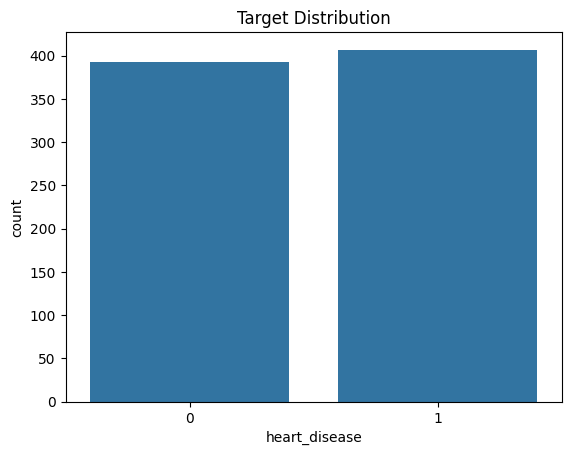

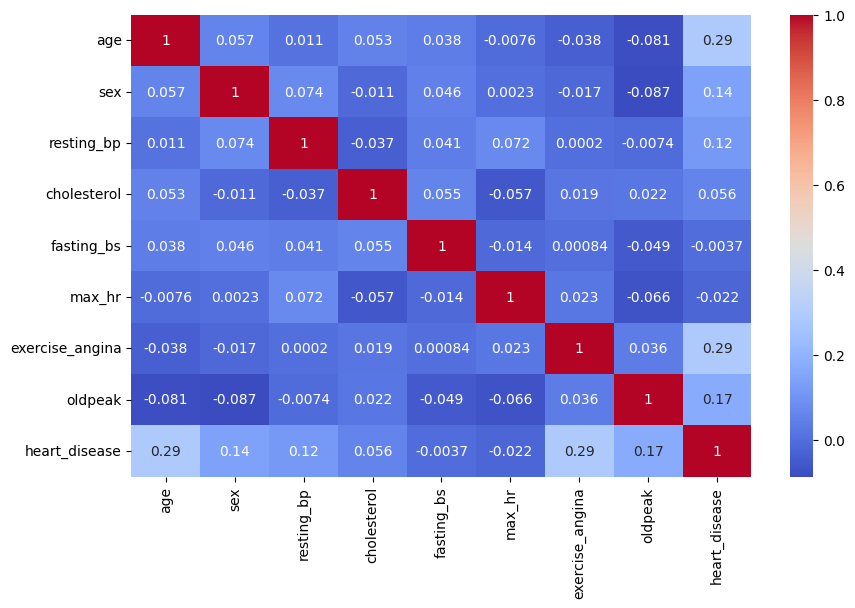


Decision Tree
[[51 21]
 [16 61]]
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        72
           1       0.74      0.79      0.77        77

    accuracy                           0.75       149
   macro avg       0.75      0.75      0.75       149
weighted avg       0.75      0.75      0.75       149


Random Forest
[[54 18]
 [17 60]]
              precision    recall  f1-score   support

           0       0.76      0.75      0.76        72
           1       0.77      0.78      0.77        77

    accuracy                           0.77       149
   macro avg       0.76      0.76      0.76       149
weighted avg       0.77      0.77      0.77       149


Gradient Boosting
[[57 15]
 [12 65]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        72
           1       0.81      0.84      0.83        77

    accuracy                           0.82       149
   macro avg       0.8

In [13]:
# =======================
# Q1: SUPERVISED LEARNING
# =======================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load Data
df = pd.read_csv('/Users/umeshkapil/Downloads/q1_heart_disease.csv')

print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.head())

# 2. EDA
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# 3. Preprocessing
df = df.dropna()

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X = pd.get_dummies(X)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# 5. Evaluation
models = {"Decision Tree": dt, "Random Forest": rf, "Gradient Boosting": gb}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# 6. Hyperparameter Tuning
params = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}

grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Tuned Model Performance:")
print(classification_report(y_test, y_pred))